# Extensions

## Binary discrimination with unequal priors

The two input states have been assumed to occur with equal
probability,

$$
P(+)=P(-)=\frac12.
$$

We now allow unequal prior probabilities,

$$
P(+)=p,
\qquad
P(-)=1-p.
$$

For two pure states with overlap $|\langle\psi_+|\psi_-\rangle|^2$, the
Helstrom minimum-error probability is

$$
P_{\mathrm{Hel}}
=
\frac12
\left[
1-
\sqrt{
1-4p(1-p)
|\langle\psi_+|\psi_-\rangle|^2
}
\right].
$$

For the coherent states $|\alpha\rangle$ and $|-\alpha\rangle$,

$$
|\langle\alpha|-\alpha\rangle|^2
=
e^{-4\bar n},
$$

so

$$
P_{\mathrm{Hel}}
=
\frac12
\left[
1-
\sqrt{
1-4p(1-p)e^{-4\bar n}
}
\right].
$$

The adaptive receiver must also account for the unequal priors when making
its final decision. For a measurement history $h$, the two weighted
likelihoods are

$$
p\,P(h|+)
$$

and

$$
(1-p)\,P(h|-).
$$

The receiver guesses whichever hypothesis has the larger weighted
likelihood.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from itertools import product
from scipy.optimize import differential_evolution

from dolinar_receiver.receivers import helstrom_error

In [2]:
def helstrom_error_priors(nbar, prior_plus=0.5):
    #Helstrom bound

    p = prior_plus

    return 0.5 * (
        1
        - np.sqrt(
            1 - 4 * p * (1 - p) * np.exp(-4 * nbar)
        )
    )

In [3]:
#For the adaptiv receiver, we use the same structure.
def adaptive_tree_error_priors(
    nbar,
    betas,
    stages,
    prior_plus=0.5
):

    expected_betas = 2 ** stages - 1

    if len(betas) != expected_betas:
        raise ValueError(
            f"{stages} stages require {expected_betas} displacement values."
        )

    alpha_bin = np.sqrt(nbar / stages)
    prior_minus = 1 - prior_plus

    total_error = 0.0

    for history in product([False, True], repeat=stages):

        p_history_plus = 1.0
        p_history_minus = 1.0

        previous_history = []

        for outcome in history:

            node = history_index(previous_history)
            beta = betas[node]

            p_history_plus *= detector_outcome_probability(
                +alpha_bin,
                beta,
                outcome
            )

            p_history_minus *= detector_outcome_probability(
                -alpha_bin,
                beta,
                outcome
            )

            previous_history.append(outcome)

        total_error += min(
            prior_plus * p_history_plus,
            prior_minus * p_history_minus
        )

    return total_error

In [4]:
#And optimize it
def optimize_adaptive_tree_priors(
    nbar,
    stages,
    prior_plus=0.5,
    seed=1234
):
    n_betas = 2 ** stages - 1

    result = differential_evolution(
        lambda betas: adaptive_tree_error_priors(
            nbar,
            betas,
            stages,
            prior_plus
        ),
        bounds=[(-3, 3)] * n_betas,
        seed=seed,
        polish=True
    )

    return result.x, result.fun

In [10]:
from dolinar_receiver.receivers import (
    no_click_probability,
    optimized_displacement,
)
#We define a function that computes the index of a node in a binary feedback tree based on the history of click/no-click outcomes.
def history_index(history):
    #Index of a node in a binary feedback tree

    if len(history) == 0:
        return 0

    binary_value = 0

    for bit in history:
        binary_value = 2 * binary_value + int(bit)

    return (2 ** len(history) - 1) + binary_value
#First , we define a function that computes the probability of a click/no-click outcome after displacement.
def detector_outcome_probability(signal, beta, clicked):
    #Probability of a click/no-click outcome after displacement

    displaced_amplitude = signal + beta
    p_no_click = no_click_probability(displaced_amplitude)

    if clicked:
        return 1 - p_no_click

    return p_no_click

In [11]:
#We can vary the prior probability and see how the error changes.
nbar_test = 0.5
stages = 3

prior_values = np.linspace(0.5, 0.95, 10)

adaptive_errors = []
helstrom_errors = []

for p in prior_values:

    _, error = optimize_adaptive_tree_priors(
        nbar_test,
        stages,
        prior_plus=p
    )

    adaptive_errors.append(error)
    helstrom_errors.append(
        helstrom_error_priors(
            nbar_test,
            prior_plus=p
        )
    )

adaptive_errors = np.array(adaptive_errors)
helstrom_errors = np.array(helstrom_errors)

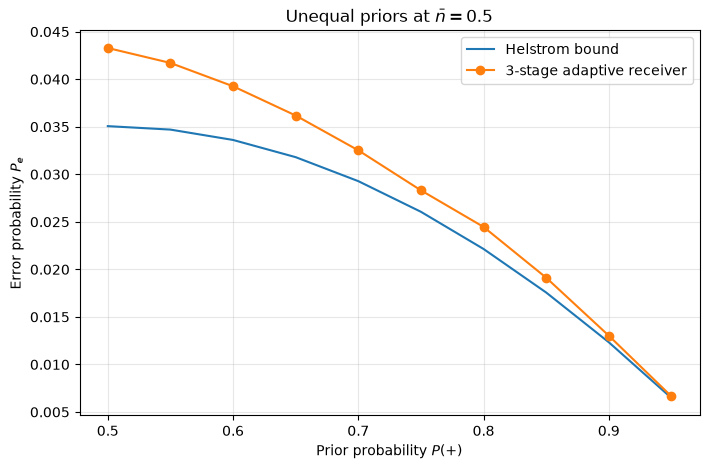

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    prior_values,
    helstrom_errors,
    label="Helstrom bound"
)

ax.plot(
    prior_values,
    adaptive_errors,
    marker="o",
    label="3-stage adaptive receiver"
)

ax.set_xlabel(r"Prior probability $P(+)$")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title(
    rf"Unequal priors at $\bar{{n}}={nbar_test}$"
)

ax.grid(alpha=0.3)
ax.legend()

plt.show()

## More than two coherent-state hypotheses

The binary Dolinar problem contains only two hypotheses. A more general
receiver may need to distinguish between several non-orthogonal coherent
states.

In this case, we can consider four equally likely phase-shifted coherent
states,

$$
|\alpha\rangle,\qquad
|i\alpha\rangle,\qquad
|-\alpha\rangle,\qquad
|-i\alpha\rangle.
$$

This won't be done here, since the problem becomes a rapidly growing optimization problem, but is studied in F. E. Becerra et al (2013). "Experimental Demonstration of a Receiver Beating the Standard Quantum Limit for Multiple Nonorthogonal State Discrimination." Nature Photonics 7: 147-152